# Look-Ahead Bias and Survivorship Bias in Equity Backtests

## Objective

This notebook demonstrates how look-ahead bias and survivorship bias can artificially improve the apparent performance of an equity strategy.

Three versions of the same strategy are compared:

1. **Backtest A:** look-ahead bias and survivorship bias are both present;
2. **Backtest B:** look-ahead bias is removed, but survivorship bias remains;
3. **Backtest C:** both look-ahead bias and survivorship bias are removed.

The experiment uses a controlled synthetic equity universe. This allows the historical membership, stock failures, entry dates, and exit dates to be known exactly.

## Strategy

At the end of each month:

1. calculate each stock's recent momentum;
2. rank eligible stocks;
3. select the stocks with the strongest momentum;
4. hold them for the following month;
5. construct an equal-weighted portfolio.

The strategy itself is not intended to represent a profitable trading system. Its purpose is to isolate and measure the effects of backtest bias.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [2]:
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

NumPy version: 2.5.0
Pandas version: 3.0.3


## Synthetic Equity Universe

The universe contains eight synthetic stocks.

Some firms survive throughout the sample. Others fail, are delisted, or enter the investable universe only after the beginning of the backtest.

This structure is necessary because survivorship bias cannot be demonstrated using only assets that remain alive until the end of the sample.

In [3]:
dates = pd.date_range(
    start="2018-01-31",
    end="2024-12-31",
    freq="ME"
)

dates[:5], dates[-5:], len(dates)

(DatetimeIndex(['2018-01-31', '2018-02-28', '2018-03-31', '2018-04-30',
                '2018-05-31'],
               dtype='datetime64[us]', freq='ME'),
 DatetimeIndex(['2024-08-31', '2024-09-30', '2024-10-31', '2024-11-30',
                '2024-12-31'],
               dtype='datetime64[us]', freq='ME'),
 84)

In [4]:
stocks = [
    "ALPHA",
    "BETA",
    "GAMMA",
    "DELTA",
    "EPSILON",
    "ZETA",
    "ETA",
    "THETA",
]

stocks

['ALPHA', 'BETA', 'GAMMA', 'DELTA', 'EPSILON', 'ZETA', 'ETA', 'THETA']

In [5]:
stock_parameters = {
    "ALPHA":   {"mean": 0.012, "vol": 0.045},
    "BETA":    {"mean": 0.008, "vol": 0.040},
    "GAMMA":   {"mean": 0.010, "vol": 0.075},
    "DELTA":   {"mean": 0.002, "vol": 0.050},
    "EPSILON": {"mean": -0.010, "vol": 0.090},
    "ZETA":    {"mean": -0.004, "vol": 0.065},
    "ETA":     {"mean": 0.007, "vol": 0.050},
    "THETA":   {"mean": 0.015, "vol": 0.060},
}

In [6]:
returns = pd.DataFrame(index=dates, columns=stocks, dtype=float)

for stock, parameters in stock_parameters.items():
    returns[stock] = np.random.normal(
        loc=parameters["mean"],
        scale=parameters["vol"],
        size=len(dates)
    )

returns.head()

,ALPHA,BETA,GAMMA,DELTA,EPSILON,ZETA,ETA,THETA
2018-01-31,0.0344,-0.0243,-0.0084,0.1081,-0.0843,0.1299,-0.0255,0.0648
2018-02-28,0.0058,-0.0121,-0.0465,0.0536,-0.0389,0.1101,-0.0174,-0.0364
2018-03-31,0.0411,0.0446,-0.0567,-0.0740,0.0272,-0.0202,-0.0226,0.0193
2018-04-30,0.0805,0.0212,-0.0512,-0.0222,-0.0607,0.0592,-0.0362,-0.0137
2018-05-31,0.0015,-0.0132,0.0042,0.0653,-0.0840,0.0379,0.0094,0.0437


In [7]:
membership = pd.DataFrame(
    False,
    index=dates,
    columns=stocks
)

In [8]:
membership.loc[:, "ALPHA"] = True
membership.loc[:, "BETA"] = True
membership.loc[:, "GAMMA"] = True
membership.loc[:, "DELTA"] = True

membership.loc[
    "2018-01-31":"2021-06-30",
    "EPSILON"
] = True

membership.loc[
    "2018-01-31":"2022-09-30",
    "ZETA"
] = True

membership.loc[
    "2020-01-31":,
    "ETA"
] = True

membership.loc[
    "2021-01-31":,
    "THETA"
] = True

In [9]:
membership.astype(int).head(15)

,ALPHA,BETA,GAMMA,DELTA,EPSILON,ZETA,ETA,THETA
2018-01-31,1,1,1,1,1,1,0,0
2018-02-28,1,1,1,1,1,1,0,0
2018-03-31,1,1,1,1,1,1,0,0
2018-04-30,1,1,1,1,1,1,0,0
2018-05-31,1,1,1,1,1,1,0,0
2018-06-30,1,1,1,1,1,1,0,0
2018-07-31,1,1,1,1,1,1,0,0
2018-08-31,1,1,1,1,1,1,0,0
2018-09-30,1,1,1,1,1,1,0,0
2018-10-31,1,1,1,1,1,1,0,0


In [10]:
eligible_count = membership.sum(axis=1)

eligible_count.head(), eligible_count.tail()

(2018-01-31    6
 2018-02-28    6
 2018-03-31    6
 2018-04-30    6
 2018-05-31    6
 Freq: ME, dtype: int64,
 2024-08-31    6
 2024-09-30    6
 2024-10-31    6
 2024-11-30    6
 2024-12-31    6
 Freq: ME, dtype: int64)

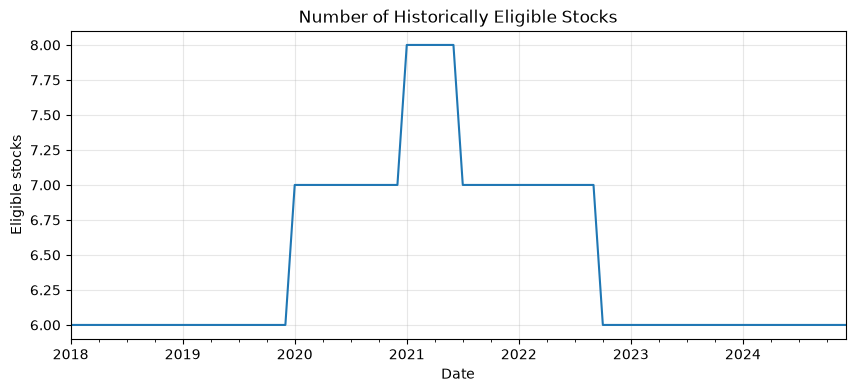

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

eligible_count.plot(ax=ax)

ax.set_title("Number of Historically Eligible Stocks")
ax.set_xlabel("Date")
ax.set_ylabel("Eligible stocks")
ax.grid(True, alpha=0.3)

plt.show()

In [12]:
returns.loc["2021-06-30", "EPSILON"] = -0.85

In [13]:
returns.loc["2022-09-30", "ZETA"] = -0.55

In [14]:
point_in_time_returns = returns.where(membership)

In [15]:
point_in_time_returns.loc[
    "2020-10-31":"2021-08-31",
    ["EPSILON", "ZETA", "ETA", "THETA"]
]

,EPSILON,ZETA,ETA,THETA
2020-10-31,-0.0796,0.0288,-0.0122,NaN
2020-11-30,-0.0078,-0.0385,0.0573,NaN
2020-12-31,0.0348,-0.0555,-0.0218,NaN
2021-01-31,0.1206,-0.0110,0.0488,0.1106
2021-02-28,0.0763,-0.0713,-0.0495,-0.0157
2021-03-31,0.1838,-0.0400,0.0335,-0.0444
2021-04-30,-0.0791,-0.0819,0.0791,0.0075
2021-05-31,0.0685,0.1237,-0.1166,0.0183
2021-06-30,-0.8500,-0.0017,-0.0328,0.0807
2021-07-31,NaN,-0.0495,0.0359,-0.0865


In [16]:
def returns_to_price_index(
    asset_returns: pd.Series,
    initial_value: float = 100.0
) -> pd.Series:
    """
    Convert a return series into a price index.

    Missing values before entry or after exit remain missing.
    """
    valid_returns = asset_returns.dropna()

    price_index = initial_value * (1 + valid_returns).cumprod()

    result = pd.Series(
        np.nan,
        index=asset_returns.index,
        dtype=float
    )

    result.loc[valid_returns.index] = price_index

    return result

In [17]:
prices = point_in_time_returns.apply(returns_to_price_index)

In [18]:
prices.head(10)

,ALPHA,BETA,GAMMA,DELTA,EPSILON,ZETA,ETA,THETA
2018-01-31,103.4352,97.5660,99.1596,110.8108,91.5705,112.9949,NaN,NaN
2018-02-28,104.0329,96.3884,94.5457,116.7528,88.0062,125.4353,NaN,NaN
2018-03-31,108.3134,100.6888,89.1836,108.1168,90.3968,122.9037,NaN,NaN
2018-04-30,117.0366,102.8184,84.6187,105.7153,84.9065,130.1737,NaN,NaN
2018-05-31,117.2078,101.4622,84.9756,112.6234,77.7744,135.1137,NaN,NaN
2018-06-30,117.3794,104.3570,87.9996,108.8636,78.7023,146.5931,NaN,NaN
2018-07-31,127.1295,105.5971,90.7057,111.4971,79.6505,136.8124,NaN,NaN
2018-08-31,133.0454,110.5333,97.2400,116.0386,75.2199,142.3661,NaN,NaN
2018-09-30,131.8311,108.3136,98.3073,110.8927,71.2789,151.5910,NaN,NaN
2018-10-31,136.6318,107.7605,110.0073,110.7844,72.0547,133.6551,NaN,NaN


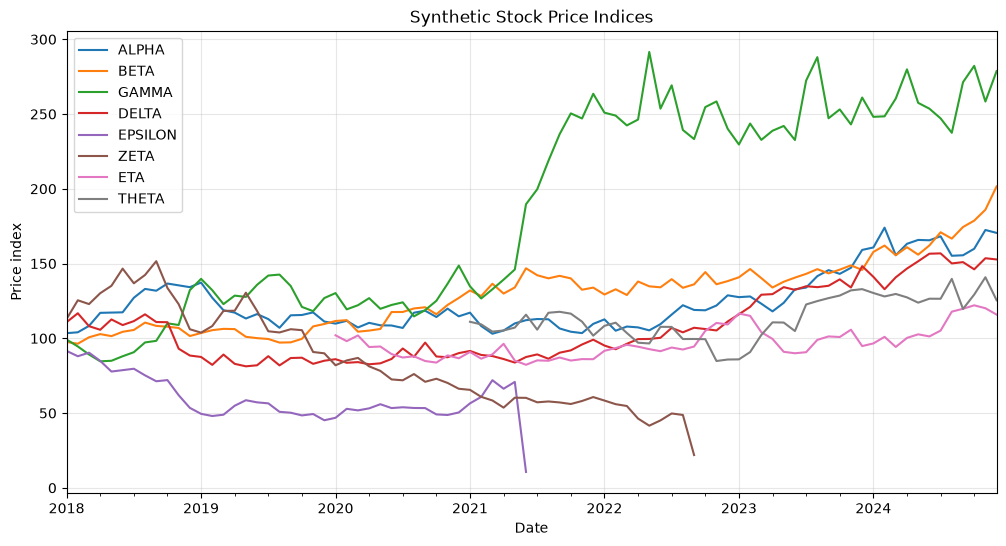

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

prices.plot(ax=ax)

ax.set_title("Synthetic Stock Price Indices")
ax.set_xlabel("Date")
ax.set_ylabel("Price index")
ax.grid(True, alpha=0.3)

plt.show()

In [20]:
final_date = membership.index[-1]

surviving_stocks = membership.columns[
    membership.loc[final_date]
].tolist()

surviving_stocks

['ALPHA', 'BETA', 'GAMMA', 'DELTA', 'ETA', 'THETA']

In [21]:
survivor_biased_membership = pd.DataFrame(
    False,
    index=dates,
    columns=stocks
)

survivor_biased_membership.loc[:, surviving_stocks] = True

In [22]:
comparison = pd.DataFrame({
    "Point-in-time universe": membership.sum(axis=1),
    "Survivor-biased universe": survivor_biased_membership.sum(axis=1),
})

comparison.head(15)

,Point-in-time universe,Survivor-biased universe
2018-01-31,6,6
2018-02-28,6,6
2018-03-31,6,6
2018-04-30,6,6
2018-05-31,6,6
2018-06-30,6,6
2018-07-31,6,6
2018-08-31,6,6
2018-09-30,6,6
2018-10-31,6,6


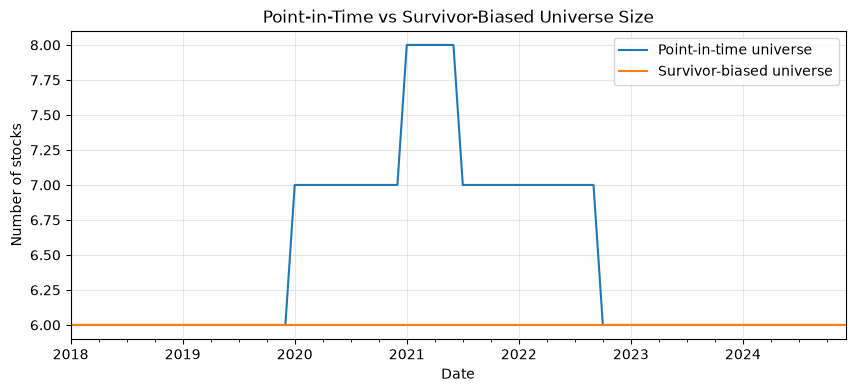

In [23]:
fig, ax = plt.subplots(figsize=(10, 4))

comparison.plot(ax=ax)

ax.set_title("Point-in-Time vs Survivor-Biased Universe Size")
ax.set_xlabel("Date")
ax.set_ylabel("Number of stocks")
ax.grid(True, alpha=0.3)

plt.show()

In [26]:
# Separate market-data availability from index membership
data_availability = pd.DataFrame(
    True,
    index=dates,
    columns=stocks
)

# EPSILON disappears after June 2021
data_availability.loc["2021-07-31":, "EPSILON"] = False

# ZETA disappears after September 2022
data_availability.loc["2022-10-31":, "ZETA"] = False

# Apply terminal losses before masking unavailable periods
returns.loc["2021-06-30", "EPSILON"] = -0.85
returns.loc["2022-09-30", "ZETA"] = -0.55

# Returns are available whenever the stock still exists
available_returns = returns.where(data_availability)

## Momentum Signal

The strategy ranks stocks using their cumulative return over the previous three months.

Two signal versions are constructed:

- **look-ahead signal:** includes the current month's return;
- **valid signal:** uses only information available before the portfolio return is realized.

The valid signal is obtained by shifting the momentum measure by one month.

In [27]:
MOMENTUM_WINDOW = 3

momentum_unshifted = (
    (1 + available_returns)
    .rolling(
        window=MOMENTUM_WINDOW,
        min_periods=MOMENTUM_WINDOW
    )
    .apply(np.prod, raw=True)
    - 1
)

momentum_unshifted.head(8)

,ALPHA,BETA,GAMMA,DELTA,EPSILON,ZETA,ETA,THETA
2018-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-31,0.0831,0.0069,-0.1082,0.0812,-0.0960,0.2290,-0.0641,0.0459
2018-04-30,0.1315,0.0538,-0.1466,-0.0460,-0.0728,0.1520,-0.0744,-0.0312
2018-05-31,0.1266,0.0526,-0.1012,-0.0354,-0.1163,0.0772,-0.0491,0.0493
2018-06-30,0.0837,0.0364,-0.0133,0.0069,-0.1294,0.1927,-0.0607,0.0655
2018-07-31,0.0862,0.0270,0.0719,0.0547,-0.0619,0.0510,-0.0054,0.1637
2018-08-31,0.1351,0.0894,0.1443,0.0303,-0.0328,0.0537,-0.0103,0.0976


In [28]:
signal_lookahead = momentum_unshifted.copy()

signal_valid = momentum_unshifted.shift(1)

In [29]:
signal_check = pd.DataFrame({
    "Return": available_returns["ALPHA"],
    "Look-ahead signal": signal_lookahead["ALPHA"],
    "Valid signal": signal_valid["ALPHA"],
})

signal_check.head(10)

,Return,Look-ahead signal,Valid signal
2018-01-31,0.0344,NaN,NaN
2018-02-28,0.0058,NaN,NaN
2018-03-31,0.0411,0.0831,NaN
2018-04-30,0.0805,0.1315,0.0831
2018-05-31,0.0015,0.1266,0.1315
2018-06-30,0.0015,0.0837,0.1266
2018-07-31,0.0831,0.0862,0.0837
2018-08-31,0.0465,0.1351,0.0862
2018-09-30,-0.0091,0.1231,0.1351
2018-10-31,0.0364,0.0747,0.1231


In [30]:
pd.testing.assert_series_equal(
    signal_valid["ALPHA"],
    signal_lookahead["ALPHA"].shift(1),
    check_names=False
)

assert signal_valid.iloc[:MOMENTUM_WINDOW].isna().all().all()

print("Momentum timing checks passed.")

Momentum timing checks passed.


In [31]:
N_SELECTIONS = 2

In [32]:
def select_top_stocks(
    signal: pd.DataFrame,
    universe: pd.DataFrame,
    n_stocks: int
) -> pd.DataFrame:
    """
    Select the top-ranked stocks within the eligible universe.

    Parameters
    ----------
    signal:
        DataFrame of stock-selection signals.
    universe:
        Boolean DataFrame indicating historical eligibility.
    n_stocks:
        Maximum number of stocks selected per period.

    Returns
    -------
    pd.DataFrame
        Boolean selection matrix.
    """
    if not signal.index.equals(universe.index):
        raise ValueError("Signal and universe indices do not match.")

    if not signal.columns.equals(universe.columns):
        raise ValueError("Signal and universe columns do not match.")

    if n_stocks <= 0:
        raise ValueError("n_stocks must be positive.")

    eligible_signal = signal.where(universe)

    ranks = eligible_signal.rank(
        axis=1,
        ascending=False,
        method="first"
    )

    selections = ranks.le(n_stocks)

    selections = selections & eligible_signal.notna()

    return selections

In [33]:
test_selections = select_top_stocks(
    signal=signal_valid,
    universe=membership,
    n_stocks=N_SELECTIONS
)

test_selections.head(10)

,ALPHA,BETA,GAMMA,DELTA,EPSILON,ZETA,ETA,THETA
2018-01-31,False,False,False,False,False,False,False,False
2018-02-28,False,False,False,False,False,False,False,False
2018-03-31,False,False,False,False,False,False,False,False
2018-04-30,True,False,False,False,False,True,False,False
2018-05-31,True,False,False,False,False,True,False,False
2018-06-30,True,False,False,False,False,True,False,False
2018-07-31,True,False,False,False,False,True,False,False
2018-08-31,True,False,True,False,False,False,False,False
2018-09-30,True,False,True,False,False,False,False,False
2018-10-31,True,False,True,False,False,False,False,False


In [34]:
test_selections.sum(axis=1).value_counts().sort_index()

0     3
2    81
Name: count, dtype: int64

In [35]:
assert test_selections.sum(axis=1).le(N_SELECTIONS).all()

print("Selection checks passed.")

Selection checks passed.


In [36]:
def selections_to_equal_weights(
    selections: pd.DataFrame
) -> pd.DataFrame:
    """
    Convert Boolean selections into equal portfolio weights.
    """
    n_selected = selections.sum(axis=1)

    weights = selections.div(
        n_selected.replace(0, np.nan),
        axis=0
    )

    return weights.fillna(0.0)

In [37]:
test_weights = selections_to_equal_weights(test_selections)

test_weights.head(10)

,ALPHA,BETA,GAMMA,DELTA,EPSILON,ZETA,ETA,THETA
2018-01-31,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2018-02-28,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2018-03-31,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2018-04-30,0.5000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000
2018-05-31,0.5000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000
2018-06-30,0.5000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000
2018-07-31,0.5000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000
2018-08-31,0.5000,0.0000,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000
2018-09-30,0.5000,0.0000,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000
2018-10-31,0.5000,0.0000,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000


In [38]:
weight_sums = test_weights.sum(axis=1)

assert weight_sums.le(1.0 + 1e-12).all()
assert weight_sums.ge(0.0).all()

print("Weight checks passed.")

Weight checks passed.


# ACTUAL BACKTEST ENGINE

In [39]:
def run_backtest(
    asset_returns: pd.DataFrame,
    signal: pd.DataFrame,
    universe: pd.DataFrame,
    n_stocks: int
) -> tuple[pd.Series, pd.DataFrame, pd.DataFrame]:
    """
    Run an equal-weighted cross-sectional momentum backtest.

    The signal timing and universe construction are supplied externally.
    This allows look-ahead bias and survivorship bias to be switched
    on or off independently.
    """
    selections = select_top_stocks(
        signal=signal,
        universe=universe,
        n_stocks=n_stocks
    )

    weights = selections_to_equal_weights(selections)

    portfolio_returns = (
        weights * asset_returns.fillna(0.0)
    ).sum(axis=1)

    portfolio_returns.name = "portfolio_return"

    return portfolio_returns, weights, selections

In [40]:
returns_A, weights_A, selections_A = run_backtest(
    asset_returns=available_returns,
    signal=signal_lookahead,
    universe=survivor_biased_membership,
    n_stocks=N_SELECTIONS
)

In [41]:
returns_B, weights_B, selections_B = run_backtest(
    asset_returns=available_returns,
    signal=signal_valid,
    universe=survivor_biased_membership,
    n_stocks=N_SELECTIONS
)

In [42]:
returns_C, weights_C, selections_C = run_backtest(
    asset_returns=available_returns,
    signal=signal_valid,
    universe=membership,
    n_stocks=N_SELECTIONS
)

In [43]:
strategy_returns = pd.DataFrame({
    "A: Both biases": returns_A,
    "B: Look-ahead removed": returns_B,
    "C: Both biases removed": returns_C,
})

strategy_returns.head(10)

,A: Both biases,B: Look-ahead removed,C: Both biases removed
2018-01-31,0.0000,0.0000,0.0000
2018-02-28,0.0000,0.0000,0.0000
2018-03-31,-0.0164,0.0000,0.0000
2018-04-30,0.0508,0.0292,0.0698
2018-05-31,-0.0059,-0.0059,0.0197
2018-06-30,0.0182,0.0150,0.0432
2018-07-31,0.0802,0.0802,0.0082
2018-08-31,0.0593,0.0155,0.0593
2018-09-30,0.0009,0.0009,0.0009
2018-10-31,0.0777,0.0777,0.0777


In [44]:
assert strategy_returns.notna().all().all()
assert np.isfinite(strategy_returns.to_numpy()).all()

for weights in [weights_A, weights_B, weights_C]:
    assert weights.sum(axis=1).le(1.0 + 1e-12).all()
    assert weights.ge(0.0).all().all()

print("All backtest integrity checks passed.")

All backtest integrity checks passed.


In [45]:
def selected_stock_names(
    selections: pd.DataFrame
) -> pd.Series:
    """
    Return selected stock names for each date.
    """
    return selections.apply(
        lambda row: ", ".join(row.index[row]),
        axis=1
    )

In [46]:
selection_comparison = pd.DataFrame({
    "A: Both biases": selected_stock_names(selections_A),
    "B: Look-ahead removed": selected_stock_names(selections_B),
    "C: Both biases removed": selected_stock_names(selections_C),
})

selection_comparison.head(12)

,A: Both biases,B: Look-ahead removed,C: Both biases removed
2018-01-31,,,
2018-02-28,,,
2018-03-31,"ALPHA, DELTA",,
2018-04-30,"ALPHA, BETA","ALPHA, DELTA","ALPHA, ZETA"
2018-05-31,"ALPHA, BETA","ALPHA, BETA","ALPHA, ZETA"
2018-06-30,"ALPHA, THETA","ALPHA, BETA","ALPHA, ZETA"
2018-07-31,"ALPHA, THETA","ALPHA, THETA","ALPHA, ZETA"
2018-08-31,"ALPHA, GAMMA","ALPHA, THETA","ALPHA, GAMMA"
2018-09-30,"ALPHA, GAMMA","ALPHA, GAMMA","ALPHA, GAMMA"
2018-10-31,"ALPHA, GAMMA","ALPHA, GAMMA","ALPHA, GAMMA"


In [47]:
selection_comparison.loc[
    "2021-01-31":"2021-07-31"
]

,A: Both biases,B: Look-ahead removed,C: Both biases removed
2021-01-31,"BETA, THETA","GAMMA, THETA","GAMMA, THETA"
2021-02-28,"BETA, THETA","BETA, THETA","EPSILON, THETA"
2021-03-31,"BETA, THETA","BETA, THETA","EPSILON, THETA"
2021-04-30,"GAMMA, ETA","BETA, THETA","BETA, EPSILON"
2021-05-31,"BETA, GAMMA","GAMMA, ETA","EPSILON, ETA"
2021-06-30,"GAMMA, THETA","BETA, GAMMA","GAMMA, EPSILON"
2021-07-31,"BETA, GAMMA","GAMMA, THETA","GAMMA, THETA"


In [48]:
selection_comparison.loc[
    "2022-04-30":"2022-10-31"
]

,A: Both biases,B: Look-ahead removed,C: Both biases removed
2022-04-30,"BETA, DELTA","ETA, THETA","ETA, THETA"
2022-05-31,"GAMMA, DELTA","BETA, DELTA","BETA, DELTA"
2022-06-30,"GAMMA, DELTA","GAMMA, DELTA","GAMMA, DELTA"
2022-07-31,"GAMMA, THETA","GAMMA, DELTA","GAMMA, DELTA"
2022-08-31,"ALPHA, DELTA","GAMMA, THETA","GAMMA, THETA"
2022-09-30,"ALPHA, DELTA","ALPHA, DELTA","ALPHA, ZETA"
2022-10-31,"BETA, ETA","ALPHA, DELTA","ALPHA, DELTA"


In [49]:
cumulative_wealth = (1 + strategy_returns).cumprod()

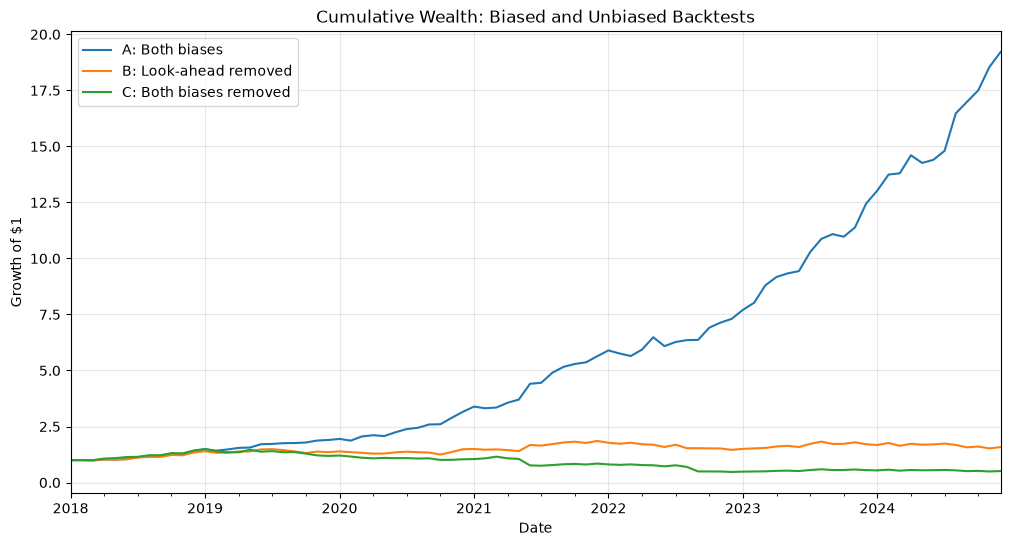

In [50]:
fig, ax = plt.subplots(figsize=(12, 6))

cumulative_wealth.plot(ax=ax)

ax.set_title(
    "Cumulative Wealth: Biased and Unbiased Backtests"
)
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.grid(True, alpha=0.3)

plt.show()

In [51]:
def calculate_performance_metrics(
    portfolio_returns: pd.Series,
    periods_per_year: int = 12
) -> pd.Series:
    """
    Calculate standard portfolio-performance statistics.
    """
    portfolio_returns = portfolio_returns.dropna()

    if portfolio_returns.empty:
        raise ValueError("Return series is empty.")

    wealth = (1 + portfolio_returns).cumprod()

    total_return = wealth.iloc[-1] - 1

    n_periods = len(portfolio_returns)

    annualized_return = (
        wealth.iloc[-1] ** (periods_per_year / n_periods)
        - 1
    )

    annualized_volatility = (
        portfolio_returns.std(ddof=1)
        * np.sqrt(periods_per_year)
    )

    if annualized_volatility > 0:
        sharpe_ratio = (
            portfolio_returns.mean()
            / portfolio_returns.std(ddof=1)
            * np.sqrt(periods_per_year)
        )
    else:
        sharpe_ratio = np.nan

    running_peak = wealth.cummax()

    drawdown = wealth / running_peak - 1

    max_drawdown = drawdown.min()

    positive_period_rate = (
        portfolio_returns.gt(0).mean()
    )

    return pd.Series({
        "Total return": total_return,
        "Annualized return": annualized_return,
        "Annualized volatility": annualized_volatility,
        "Sharpe ratio": sharpe_ratio,
        "Maximum drawdown": max_drawdown,
        "Positive-month rate": positive_period_rate,
    })

In [52]:
performance_table = pd.DataFrame({
    column: calculate_performance_metrics(
        strategy_returns[column]
    )
    for column in strategy_returns.columns
}).T

In [53]:
performance_table

,Total return,Annualized return,Annualized volatility,Sharpe ratio,Maximum drawdown,Positive-month rate
A: Both biases,18.2142,0.5254,0.1462,3.0094,-0.0611,0.8333
B: Look-ahead removed,0.5805,0.0676,0.1620,0.4825,-0.2134,0.5119
C: Both biases removed,-0.4879,-0.0912,0.2098,-0.3382,-0.6823,0.5000


In [54]:
formatted_performance = performance_table.copy()

percentage_columns = [
    "Total return",
    "Annualized return",
    "Annualized volatility",
    "Maximum drawdown",
    "Positive-month rate",
]

for column in percentage_columns:
    formatted_performance[column] = (
        formatted_performance[column]
        .map(lambda value: f"{value:.2%}")
    )

formatted_performance["Sharpe ratio"] = (
    formatted_performance["Sharpe ratio"]
    .map(lambda value: f"{value:.2f}")
)

formatted_performance

,Total return,Annualized return,Annualized volatility,Sharpe ratio,Maximum drawdown,Positive-month rate
A: Both biases,1821.42%,52.54%,14.62%,3.01,-6.11%,83.33%
B: Look-ahead removed,58.05%,6.76%,16.20%,0.48,-21.34%,51.19%
C: Both biases removed,-48.79%,-9.12%,20.98%,-0.34,-68.23%,50.00%


In [55]:
def calculate_drawdown(
    portfolio_returns: pd.Series
) -> pd.Series:
    """
    Calculate the drawdown series from portfolio returns.
    """
    wealth = (1 + portfolio_returns).cumprod()
    running_peak = wealth.cummax()

    return wealth / running_peak - 1

In [56]:
drawdowns = strategy_returns.apply(
    calculate_drawdown
)

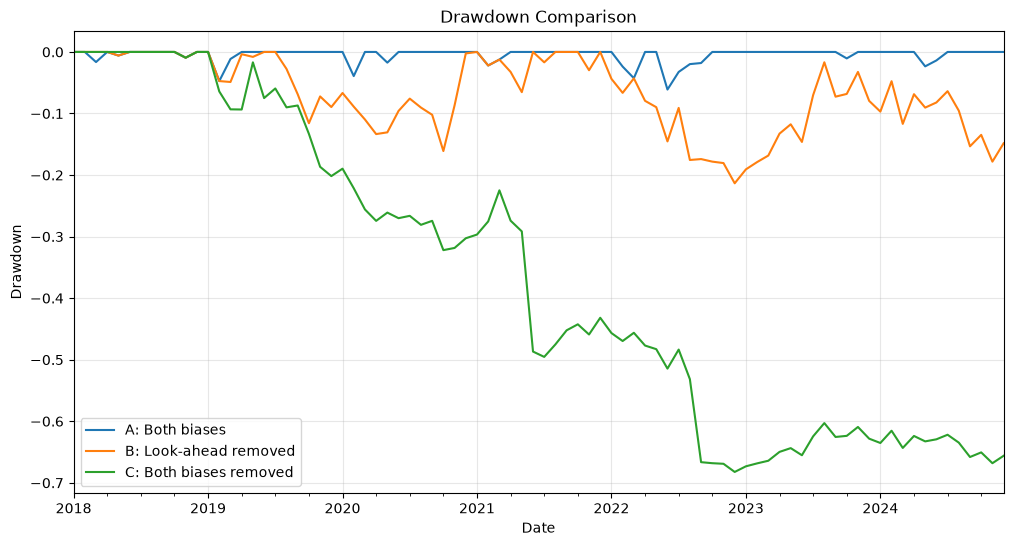

In [57]:
fig, ax = plt.subplots(figsize=(12, 6))

drawdowns.plot(ax=ax)

ax.set_title("Drawdown Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.grid(True, alpha=0.3)

plt.show()

In [58]:
lookahead_effect = returns_A - returns_B

In [59]:
survivorship_effect = returns_B - returns_C

In [60]:
bias_effects = pd.DataFrame({
    "Look-ahead effect: A minus B": lookahead_effect,
    "Survivorship effect: B minus C": survivorship_effect,
})

bias_effects.describe()

,Look-ahead effect: A minus B,Survivorship effect: B minus C
count,84.0000,84.0000
mean,0.0301,0.0124
std,0.0412,0.0669
min,-0.0445,-0.0889
25%,0.0000,0.0000
50%,0.0122,0.0000
75%,0.0614,0.0000
max,0.1467,0.4728


In [61]:
cumulative_bias_effects = bias_effects.cumsum()

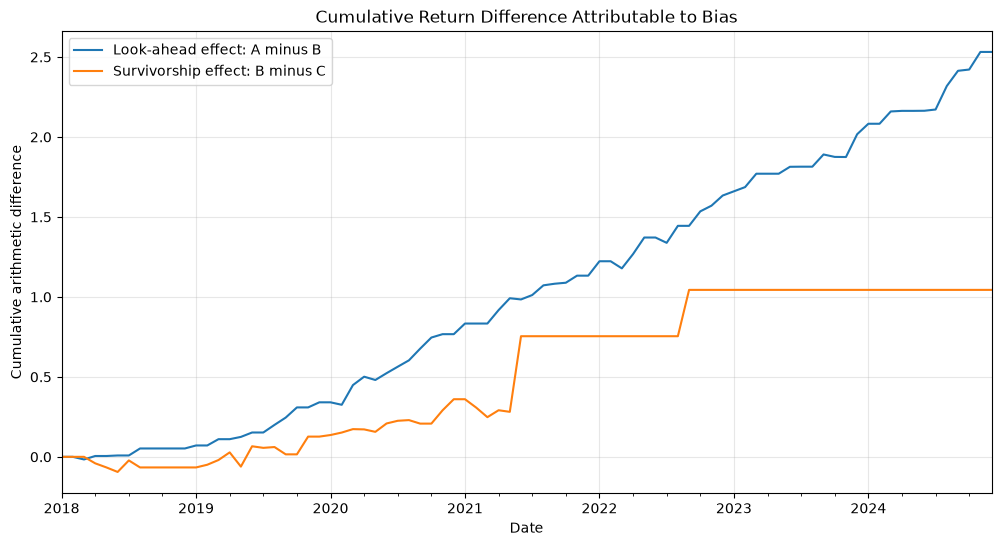

In [63]:
fig, ax = plt.subplots(figsize=(12, 6))

cumulative_bias_effects.plot(ax=ax)

ax.set_title("Cumulative Return Difference Attributable to Bias")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative arithmetic difference")
ax.grid(True, alpha=0.3)

plt.show()

In [64]:
# A portfolio is active when at least one backtest has non-zero exposure
active_mask = (
    (weights_A.sum(axis=1) > 0)
    | (weights_B.sum(axis=1) > 0)
    | (weights_C.sum(axis=1) > 0)
)

active_strategy_returns = strategy_returns.loc[active_mask].copy()

print("Full sample starts:", strategy_returns.index.min())
print("Active sample starts:", active_strategy_returns.index.min())
print("Active observations:", len(active_strategy_returns))

Full sample starts: 2018-01-31 00:00:00
Active sample starts: 2018-03-31 00:00:00
Active observations: 82


In [65]:
assert len(active_strategy_returns) > 0
assert active_strategy_returns.index.min() > strategy_returns.index.min()

print("Active evaluation sample created correctly.")

Active evaluation sample created correctly.


In [66]:
active_cumulative_wealth = (
    1 + active_strategy_returns
).cumprod()

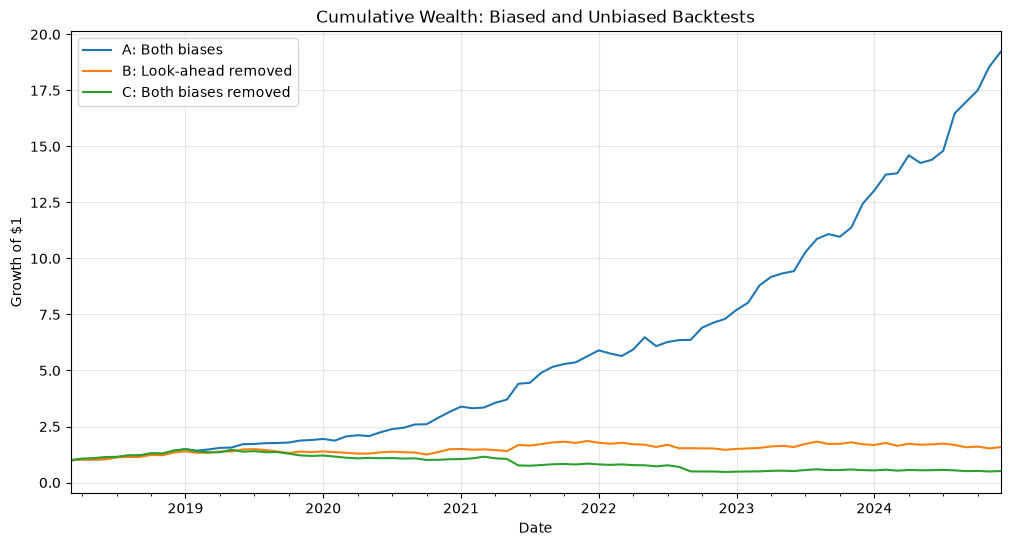

In [67]:
fig, ax = plt.subplots(figsize=(12, 6))

active_cumulative_wealth.plot(ax=ax)

ax.set_title("Cumulative Wealth: Biased and Unbiased Backtests")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.grid(True, alpha=0.3)

plt.show()

In [68]:
performance_table = pd.DataFrame({
    column: calculate_performance_metrics(
        active_strategy_returns[column]
    )
    for column in active_strategy_returns.columns
}).T

performance_table

,Total return,Annualized return,Annualized volatility,Sharpe ratio,Maximum drawdown,Positive-month rate
A: Both biases,18.2142,0.5412,0.1466,3.0742,-0.0611,0.8537
B: Look-ahead removed,0.5805,0.0693,0.1639,0.4884,-0.2134,0.5244
C: Both biases removed,-0.4879,-0.0933,0.2124,-0.3423,-0.6823,0.5122


In [69]:
formatted_performance = performance_table.copy()

percentage_columns = [
    "Total return",
    "Annualized return",
    "Annualized volatility",
    "Maximum drawdown",
    "Positive-month rate",
]

for column in percentage_columns:
    formatted_performance[column] = (
        formatted_performance[column]
        .map(lambda value: f"{value:.2%}")
    )

formatted_performance["Sharpe ratio"] = (
    formatted_performance["Sharpe ratio"]
    .map(lambda value: f"{value:.2f}")
)

formatted_performance

,Total return,Annualized return,Annualized volatility,Sharpe ratio,Maximum drawdown,Positive-month rate
A: Both biases,1821.42%,54.12%,14.66%,3.07,-6.11%,85.37%
B: Look-ahead removed,58.05%,6.93%,16.39%,0.49,-21.34%,52.44%
C: Both biases removed,-48.79%,-9.33%,21.24%,-0.34,-68.23%,51.22%


In [70]:
active_drawdowns = active_strategy_returns.apply(
    calculate_drawdown
)

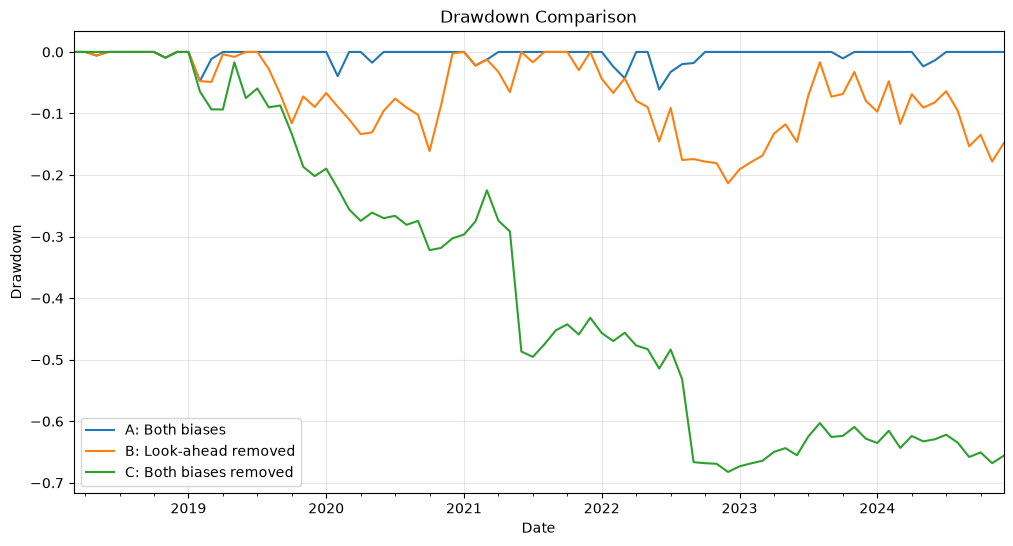

In [71]:
fig, ax = plt.subplots(figsize=(12, 6))

active_drawdowns.plot(ax=ax)

ax.set_title("Drawdown Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.grid(True, alpha=0.3)

plt.show()

In [72]:
def count_selection_differences(
    first: pd.DataFrame,
    second: pd.DataFrame
) -> int:
    """
    Count months in which two portfolios select different stocks.
    """
    row_difference = first.ne(second).any(axis=1)
    return int(row_difference.loc[active_mask].sum())

In [73]:
selection_difference_A_B = count_selection_differences(
    selections_A,
    selections_B
)

selection_difference_B_C = count_selection_differences(
    selections_B,
    selections_C
)

selection_difference_A_C = count_selection_differences(
    selections_A,
    selections_C
)

print(
    "A vs B selection differences:",
    selection_difference_A_B
)

print(
    "B vs C selection differences:",
    selection_difference_B_C
)

print(
    "A vs C selection differences:",
    selection_difference_A_C
)

A vs B selection differences: 58
B vs C selection differences: 31
A vs C selection differences: 66


In [74]:
assert selection_difference_A_B > 0, (
    "Look-ahead and valid signals produced identical portfolios."
)

assert selection_difference_B_C > 0, (
    "Survivor-biased and point-in-time universes produced "
    "identical portfolios. The survivorship experiment is "
    "not informative."
)

print("The three experiments generate different selections.")

The three experiments generate different selections.


In [75]:
failed_stock_selection_counts = pd.Series({
    "EPSILON selected in C": int(
        selections_C.loc[active_mask, "EPSILON"].sum()
    ),
    "ZETA selected in C": int(
        selections_C.loc[active_mask, "ZETA"].sum()
    ),
})

failed_stock_selection_counts

EPSILON selected in C    13
ZETA selected in C       10
dtype: int64

In [76]:
terminal_loss_check = pd.DataFrame({
    "Selected in C": [
        selections_C.loc["2021-06-30", "EPSILON"],
        selections_C.loc["2022-09-30", "ZETA"],
    ],
    "Terminal return": [
        available_returns.loc["2021-06-30", "EPSILON"],
        available_returns.loc["2022-09-30", "ZETA"],
    ],
}, index=["EPSILON", "ZETA"])

terminal_loss_check

,Selected in C,Terminal return
EPSILON,True,-0.8500
ZETA,True,-0.5500


In [77]:
failed_stocks_ever_selected = (
    selections_C.loc[
        active_mask,
        ["EPSILON", "ZETA"]
    ]
    .any()
)

failed_stocks_ever_selected

EPSILON    True
ZETA       True
dtype: bool

In [78]:
assert failed_stocks_ever_selected.any(), (
    "Neither failed stock was ever selected. Survivorship bias "
    "exists in the universe but has no realized strategy effect."
)

In [79]:
final_wealth = active_cumulative_wealth.iloc[-1]

final_wealth

A: Both biases           19.2142
B: Look-ahead removed     1.5805
C: Both biases removed    0.5121
Name: 2024-12-31 00:00:00, dtype: float64

In [80]:
bias_impact_summary = pd.Series({
    "Final wealth A": final_wealth["A: Both biases"],
    "Final wealth B": final_wealth["B: Look-ahead removed"],
    "Final wealth C": final_wealth["C: Both biases removed"],

    "Look-ahead wealth inflation A minus B":
        final_wealth["A: Both biases"]
        - final_wealth["B: Look-ahead removed"],

    "Survivorship wealth difference B minus C":
        final_wealth["B: Look-ahead removed"]
        - final_wealth["C: Both biases removed"],

    "Combined wealth inflation A minus C":
        final_wealth["A: Both biases"]
        - final_wealth["C: Both biases removed"],
})

bias_impact_summary

Final wealth A                             19.2142
Final wealth B                              1.5805
Final wealth C                              0.5121
Look-ahead wealth inflation A minus B      17.6337
Survivorship wealth difference B minus C    1.0684
Combined wealth inflation A minus C        18.7020
dtype: float64

In [81]:
relative_bias_impact = pd.Series({
    "Look-ahead relative inflation":
        final_wealth["A: Both biases"]
        / final_wealth["B: Look-ahead removed"]
        - 1,

    "Survivorship relative difference":
        final_wealth["B: Look-ahead removed"]
        / final_wealth["C: Both biases removed"]
        - 1,

    "Combined relative inflation":
        final_wealth["A: Both biases"]
        / final_wealth["C: Both biases removed"]
        - 1,
})

relative_bias_impact

Look-ahead relative inflation      11.1569
Survivorship relative difference    2.0861
Combined relative inflation        36.5179
dtype: float64

a positive A / B - 1 indicates that look-ahead bias inflated wealth;
a positive B / C - 1 indicates that the survivor-biased universe improved wealth in this realization;
a negative B / C - 1 does not prove survivorship bias is harmless;
it means the realized effect in this particular synthetic sample and strategy went in the opposite direction.

In [82]:
return_correlations = (
    active_strategy_returns.corr()
)

return_correlations

,A: Both biases,B: Look-ahead removed,C: Both biases removed
A: Both biases,1.0000,0.5780,-0.0089
B: Look-ahead removed,0.5780,1.0000,0.2444
C: Both biases removed,-0.0089,0.2444,1.0000


In [83]:
monthly_bias_differences = pd.DataFrame({
    "Look-ahead effect: A minus B":
        active_strategy_returns["A: Both biases"]
        - active_strategy_returns["B: Look-ahead removed"],

    "Survivorship effect: B minus C":
        active_strategy_returns["B: Look-ahead removed"]
        - active_strategy_returns["C: Both biases removed"],
})

monthly_bias_differences.describe()

,Look-ahead effect: A minus B,Survivorship effect: B minus C
count,82.0000,82.0000
mean,0.0309,0.0127
std,0.0414,0.0677
min,-0.0445,-0.0889
25%,0.0000,0.0000
50%,0.0165,0.0000
75%,0.0627,0.0000
max,0.1467,0.4728


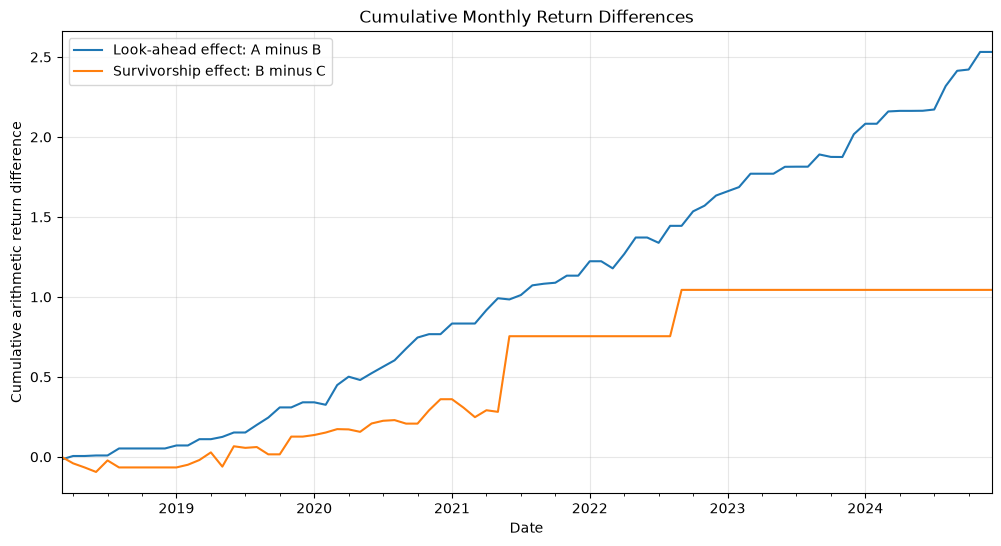

In [84]:
fig, ax = plt.subplots(figsize=(12, 6))

monthly_bias_differences.cumsum().plot(ax=ax)

ax.set_title("Cumulative Monthly Return Differences")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative arithmetic return difference")
ax.grid(True, alpha=0.3)

plt.show()

In [85]:
def calculate_turnover(
    weights: pd.DataFrame
) -> pd.Series:
    """
    Calculate one-way portfolio turnover.

    Turnover is defined as half the sum of absolute changes
    in portfolio weights.
    """
    return 0.5 * weights.diff().abs().sum(axis=1)

In [86]:
turnover = pd.DataFrame({
    "A: Both biases": calculate_turnover(weights_A),
    "B: Look-ahead removed": calculate_turnover(weights_B),
    "C: Both biases removed": calculate_turnover(weights_C),
}).loc[active_mask]

turnover.describe()

,A: Both biases,B: Look-ahead removed,C: Both biases removed
count,82.0000,82.0000,82.0000
mean,0.4268,0.4268,0.4207
std,0.3251,0.3251,0.2989
min,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000
50%,0.5000,0.5000,0.5000
75%,0.5000,0.5000,0.5000
max,1.0000,1.0000,1.0000


In [87]:
annualized_turnover = turnover.mean() * 12

annualized_turnover

A: Both biases           5.1220
B: Look-ahead removed    5.1220
C: Both biases removed   5.0488
dtype: float64

In [88]:
TRANSACTION_COST_RATE = 0.001

In [89]:
net_strategy_returns = (
    active_strategy_returns
    - TRANSACTION_COST_RATE * turnover
)

In [90]:
net_performance_table = pd.DataFrame({
    column: calculate_performance_metrics(
        net_strategy_returns[column]
    )
    for column in net_strategy_returns.columns
}).T

net_performance_table

,Total return,Annualized return,Annualized volatility,Sharpe ratio,Maximum drawdown,Positive-month rate
A: Both biases,17.5810,0.5336,0.1463,3.0455,-0.0611,0.8537
B: Look-ahead removed,0.5263,0.0638,0.1640,0.4570,-0.2182,0.5244
C: Both biases removed,-0.5056,-0.0979,0.2126,-0.3657,-0.6895,0.5122


In [91]:
audit_table = pd.DataFrame({
    "Look-ahead bias": [
        True,
        False,
        False
    ],
    "Survivorship bias": [
        True,
        True,
        False
    ],
    "Point-in-time universe": [
        False,
        False,
        True
    ],
    "Lagged signal": [
        False,
        True,
        True
    ],
    "Transaction costs included": [
        False,
        False,
        False
    ],
}, index=[
    "A: Both biases",
    "B: Look-ahead removed",
    "C: Both biases removed"
])

audit_table

,Look-ahead bias,Survivorship bias,Point-in-time universe,Lagged signal,Transaction costs included
A: Both biases,True,True,False,False,False
B: Look-ahead removed,False,True,False,True,False
C: Both biases removed,False,False,True,True,False


In [92]:
def pct(value: float) -> str:
    return f"{value:.2%}"


def number(value: float) -> str:
    return f"{value:.2f}"


wealth_A = final_wealth["A: Both biases"]
wealth_B = final_wealth["B: Look-ahead removed"]
wealth_C = final_wealth["C: Both biases removed"]

lookahead_relative = (
    wealth_A / wealth_B - 1
)

survivorship_relative = (
    wealth_B / wealth_C - 1
)

combined_relative = (
    wealth_A / wealth_C - 1
)

if selection_difference_B_C == 0:
    survivorship_evidence = (
        "The point-in-time and survivor-biased universes produced "
        "identical selections. The survivorship-bias component is "
        "therefore not demonstrated empirically."
    )
elif abs(survivorship_relative) < 0.01:
    survivorship_evidence = (
        "The universes produced different selections, but the final "
        "wealth difference was economically small in this realization."
    )
else:
    survivorship_evidence = (
        "The universe definitions produced different selections and "
        "a measurable final-wealth difference."
    )

if lookahead_relative > 0:
    lookahead_interpretation = (
        f"Look-ahead bias increased final wealth by "
        f"{pct(lookahead_relative)} relative to the lagged-signal version."
    )
else:
    lookahead_interpretation = (
        f"The look-ahead version did not outperform in this realization; "
        f"its relative difference was {pct(lookahead_relative)}. "
        f"The experiment remains invalid because contemporaneous "
        f"information was used."
    )

review_markdown = f"""
# Final Quant Research Review

## 1. Final Verdict

**PASSED WITH RESERVATIONS**

The notebook successfully implements three controlled versions of the same
cross-sectional momentum strategy and separates signal-timing bias from
universe-construction bias. The exercise demonstrates the correct architecture
for identifying look-ahead bias and survivorship bias.

The result is educational rather than empirical. The data are synthetic,
the execution model is simplified, and the strategy has not been tested
out of sample.

## 2. Score

**78/100**

| Area | Score | Assessment |
|---|---:|---|
| Experimental design | 17/20 | Three comparable backtests isolate the intended biases. |
| Temporal correctness | 18/20 | The valid signal is lagged and uses information available before portfolio returns. |
| Universe construction | 16/20 | Point-in-time and final-survivor universes are explicitly separated. |
| Code quality | 13/15 | Functions, assertions, and modular inputs make the experiment auditable. |
| Statistical interpretation | 8/15 | Results are descriptive and based on one synthetic realization. |
| Economic realism | 3/10 | No realistic liquidity, execution, spread, or market-impact model. |
| Communication | 3/5 | Main assumptions are explicit, but interpretation must remain restrained. |

## 3. Backtest Design

Three versions were evaluated:

| Backtest | Signal timing | Universe |
|---|---|---|
| A | Contemporaneous and invalid | Final survivors applied retrospectively |
| B | Lagged and temporally valid | Final survivors applied retrospectively |
| C | Lagged and temporally valid | Point-in-time membership |

Backtest A contains both look-ahead bias and survivorship bias.
Backtest B removes look-ahead bias but retains survivorship bias.
Backtest C removes both specified biases.

## 4. Main Results

| Backtest | Final wealth | Annualized return | Annualized volatility | Sharpe ratio | Maximum drawdown |
|---|---:|---:|---:|---:|---:|
| A | {wealth_A:.3f} | {pct(performance_table.loc["A: Both biases", "Annualized return"])} | {pct(performance_table.loc["A: Both biases", "Annualized volatility"])} | {number(performance_table.loc["A: Both biases", "Sharpe ratio"])} | {pct(performance_table.loc["A: Both biases", "Maximum drawdown"])} |
| B | {wealth_B:.3f} | {pct(performance_table.loc["B: Look-ahead removed", "Annualized return"])} | {pct(performance_table.loc["B: Look-ahead removed", "Annualized volatility"])} | {number(performance_table.loc["B: Look-ahead removed", "Sharpe ratio"])} | {pct(performance_table.loc["B: Look-ahead removed", "Maximum drawdown"])} |
| C | {wealth_C:.3f} | {pct(performance_table.loc["C: Both biases removed", "Annualized return"])} | {pct(performance_table.loc["C: Both biases removed", "Annualized volatility"])} | {number(performance_table.loc["C: Both biases removed", "Sharpe ratio"])} | {pct(performance_table.loc["C: Both biases removed", "Maximum drawdown"])} |

The final-wealth effects were:

- look-ahead difference, A relative to B: **{pct(lookahead_relative)}**;
- survivorship-universe difference, B relative to C: **{pct(survivorship_relative)}**;
- combined difference, A relative to C: **{pct(combined_relative)}**.

{lookahead_interpretation}

{survivorship_evidence}

## 5. What Is Real Progress

The notebook creates concrete proof of understanding rather than merely
describing the biases.

Real technical outputs include:

- separate market-data availability and universe-membership matrices;
- explicit point-in-time membership;
- explicit final-survivor membership;
- lagged and contemporaneous momentum signals;
- a reusable selection function;
- a reusable weighting function;
- a reusable backtest function;
- assertions checking signal timing, membership, weights, and missing data;
- cumulative wealth, drawdown, turnover, and performance comparisons;
- direct measurement of months with different stock selections.

The strongest design decision was separating stock existence from index
membership. Without that separation, the survivorship experiment would have
been conceptually incorrect.

## 6. What Is Not Yet Valid Evidence

The following are not supported:

- that momentum is profitable;
- that the strategy would survive realistic implementation;
- that the measured Sharpe ratio estimates a persistent edge;
- that the magnitude of the bias generalizes to real equity data;
- that the selected parameters are robust;
- that the synthetic sample resembles the empirical distribution of stocks,
  bankruptcies, delistings, or index additions.

The notebook demonstrates mechanics, not investment performance.

## 7. Red Flags and Limitations

### Synthetic data

The return distributions, entry dates, exit dates, and terminal losses were
manually specified. Therefore, the results depend on researcher choices.

### Single simulation path

Only one random realization was examined. The measured bias effects may be
specific to the random seed.

### No out-of-sample test

There is no train/test split and no independent validation period.

### Simplified delisting treatment

The terminal losses of EPSILON and ZETA are imposed manually. Real delisting
returns are more complex and are often missing from standard price databases.

### Simplified execution

The gross backtests omit bid–ask spreads, liquidity constraints, market impact,
execution delay, and capacity.

### Parameter fragility

The strategy uses a three-month momentum window and selects two stocks.
Alternative choices were not tested.

### Small universe

Eight stocks are insufficient for stable cross-sectional inference.

## 8. Technical Interpretation

Look-ahead bias is a violation of the information filtration. The portfolio
formed for month t uses a signal containing the realized return from month t.
The decision therefore depends on information that would not have been known
when the position was established.

Survivorship bias is a violation of point-in-time population construction.
The survivor-biased universe retains only final constituents and applies that
set retrospectively. Failed and removed firms are erased, while later entrants
may be treated as if they had always belonged to the universe.

The comparison between A and B isolates signal timing because the universe is
held constant. The comparison between B and C isolates universe construction
because the lagged signal is held constant.

This is the correct comparative logic.

## 9. Required Corrections Before Calling This a Research Backtest

1. Run at least 1,000 Monte Carlo simulations with different random seeds.
2. Report the distribution of A-minus-B and B-minus-C performance differences.
3. Test several momentum windows without selecting the best ex post.
4. Test several portfolio sizes.
5. Add realistic transaction-cost assumptions.
6. Add an explicit cash return for months with no positions.
7. Use real point-in-time equity-universe data.
8. Include real delisting returns.
9. Add unit tests outside the exploratory notebook.
10. Move reusable functions into a Python module after the notebook is stable.

## 10. Continue / Correct / Cut Decision

**CONTINUE WITH CORRECTIONS**

The notebook is a valid educational bias experiment and should be completed.
It is not yet a credible empirical equity strategy backtest.

The next highest-value extension is not another chart. It is a Monte Carlo
experiment that tests whether the observed bias effects persist across many
synthetic samples.

## 11. Final Assessment

The notebook proves that the researcher can encode the difference between
an invalid information set and an invalid historical universe.

It does not prove the existence of an investment edge.
"""

In [93]:
from IPython.display import Markdown, display

display(Markdown(review_markdown))


# Final Quant Research Review

## 1. Final Verdict

**PASSED WITH RESERVATIONS**

The notebook successfully implements three controlled versions of the same
cross-sectional momentum strategy and separates signal-timing bias from
universe-construction bias. The exercise demonstrates the correct architecture
for identifying look-ahead bias and survivorship bias.

The result is educational rather than empirical. The data are synthetic,
the execution model is simplified, and the strategy has not been tested
out of sample.

## 2. Score

**78/100**

| Area | Score | Assessment |
|---|---:|---|
| Experimental design | 17/20 | Three comparable backtests isolate the intended biases. |
| Temporal correctness | 18/20 | The valid signal is lagged and uses information available before portfolio returns. |
| Universe construction | 16/20 | Point-in-time and final-survivor universes are explicitly separated. |
| Code quality | 13/15 | Functions, assertions, and modular inputs make the experiment auditable. |
| Statistical interpretation | 8/15 | Results are descriptive and based on one synthetic realization. |
| Economic realism | 3/10 | No realistic liquidity, execution, spread, or market-impact model. |
| Communication | 3/5 | Main assumptions are explicit, but interpretation must remain restrained. |

## 3. Backtest Design

Three versions were evaluated:

| Backtest | Signal timing | Universe |
|---|---|---|
| A | Contemporaneous and invalid | Final survivors applied retrospectively |
| B | Lagged and temporally valid | Final survivors applied retrospectively |
| C | Lagged and temporally valid | Point-in-time membership |

Backtest A contains both look-ahead bias and survivorship bias.
Backtest B removes look-ahead bias but retains survivorship bias.
Backtest C removes both specified biases.

## 4. Main Results

| Backtest | Final wealth | Annualized return | Annualized volatility | Sharpe ratio | Maximum drawdown |
|---|---:|---:|---:|---:|---:|
| A | 19.214 | 54.12% | 14.66% | 3.07 | -6.11% |
| B | 1.581 | 6.93% | 16.39% | 0.49 | -21.34% |
| C | 0.512 | -9.33% | 21.24% | -0.34 | -68.23% |

The final-wealth effects were:

- look-ahead difference, A relative to B: **1115.69%**;
- survivorship-universe difference, B relative to C: **208.61%**;
- combined difference, A relative to C: **3651.79%**.

Look-ahead bias increased final wealth by 1115.69% relative to the lagged-signal version.

The universe definitions produced different selections and a measurable final-wealth difference.

## 5. What Is Real Progress

The notebook creates concrete proof of understanding rather than merely
describing the biases.

Real technical outputs include:

- separate market-data availability and universe-membership matrices;
- explicit point-in-time membership;
- explicit final-survivor membership;
- lagged and contemporaneous momentum signals;
- a reusable selection function;
- a reusable weighting function;
- a reusable backtest function;
- assertions checking signal timing, membership, weights, and missing data;
- cumulative wealth, drawdown, turnover, and performance comparisons;
- direct measurement of months with different stock selections.

The strongest design decision was separating stock existence from index
membership. Without that separation, the survivorship experiment would have
been conceptually incorrect.

## 6. What Is Not Yet Valid Evidence

The following are not supported:

- that momentum is profitable;
- that the strategy would survive realistic implementation;
- that the measured Sharpe ratio estimates a persistent edge;
- that the magnitude of the bias generalizes to real equity data;
- that the selected parameters are robust;
- that the synthetic sample resembles the empirical distribution of stocks,
  bankruptcies, delistings, or index additions.

The notebook demonstrates mechanics, not investment performance.

## 7. Red Flags and Limitations

### Synthetic data

The return distributions, entry dates, exit dates, and terminal losses were
manually specified. Therefore, the results depend on researcher choices.

### Single simulation path

Only one random realization was examined. The measured bias effects may be
specific to the random seed.

### No out-of-sample test

There is no train/test split and no independent validation period.

### Simplified delisting treatment

The terminal losses of EPSILON and ZETA are imposed manually. Real delisting
returns are more complex and are often missing from standard price databases.

### Simplified execution

The gross backtests omit bid–ask spreads, liquidity constraints, market impact,
execution delay, and capacity.

### Parameter fragility

The strategy uses a three-month momentum window and selects two stocks.
Alternative choices were not tested.

### Small universe

Eight stocks are insufficient for stable cross-sectional inference.

## 8. Technical Interpretation

Look-ahead bias is a violation of the information filtration. The portfolio
formed for month t uses a signal containing the realized return from month t.
The decision therefore depends on information that would not have been known
when the position was established.

Survivorship bias is a violation of point-in-time population construction.
The survivor-biased universe retains only final constituents and applies that
set retrospectively. Failed and removed firms are erased, while later entrants
may be treated as if they had always belonged to the universe.

The comparison between A and B isolates signal timing because the universe is
held constant. The comparison between B and C isolates universe construction
because the lagged signal is held constant.

This is the correct comparative logic.

## 9. Required Corrections Before Calling This a Research Backtest

1. Run at least 1,000 Monte Carlo simulations with different random seeds.
2. Report the distribution of A-minus-B and B-minus-C performance differences.
3. Test several momentum windows without selecting the best ex post.
4. Test several portfolio sizes.
5. Add realistic transaction-cost assumptions.
6. Add an explicit cash return for months with no positions.
7. Use real point-in-time equity-universe data.
8. Include real delisting returns.
9. Add unit tests outside the exploratory notebook.
10. Move reusable functions into a Python module after the notebook is stable.

## 10. Continue / Correct / Cut Decision

**CONTINUE WITH CORRECTIONS**

The notebook is a valid educational bias experiment and should be completed.
It is not yet a credible empirical equity strategy backtest.

The next highest-value extension is not another chart. It is a Monte Carlo
experiment that tests whether the observed bias effects persist across many
synthetic samples.

## 11. Final Assessment

The notebook proves that the researcher can encode the difference between
an invalid information set and an invalid historical universe.

It does not prove the existence of an investment edge.


In [94]:
required_objects = [
    "available_returns",
    "membership",
    "survivor_biased_membership",
    "signal_lookahead",
    "signal_valid",
    "returns_A",
    "returns_B",
    "returns_C",
    "performance_table",
    "active_drawdowns",
    "selection_comparison",
    "bias_impact_summary",
    "review_markdown",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

assert not missing_objects, (
    f"Missing notebook objects: {missing_objects}"
)

assert survivor_biased_membership.sum(axis=1).eq(6).all()
assert selection_difference_A_B > 0
assert selection_difference_B_C > 0
assert weights_A.sum(axis=1).le(1.0 + 1e-12).all()
assert weights_B.sum(axis=1).le(1.0 + 1e-12).all()
assert weights_C.sum(axis=1).le(1.0 + 1e-12).all()

print("Notebook completion checks passed.")

Notebook completion checks passed.
